In [2]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense,Flatten

In [3]:
from tensorflow.keras.datasets import cifar10


In [4]:
(X_train,y_train),(X_test,y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


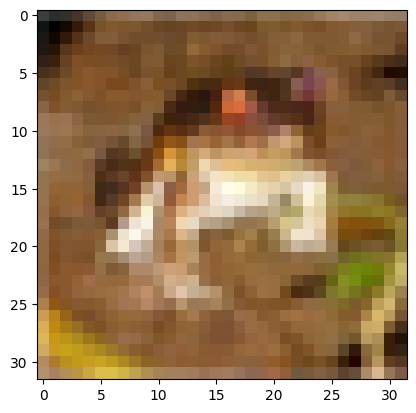

In [5]:
import matplotlib.pyplot as plt
plt.imshow(X_train[0])

In [6]:
y_train[0]

array([6], dtype=uint8)

In [7]:
X_train.shape,y_train.shape

((50000, 32, 32, 3), (50000, 1))

In [8]:
X_test.shape,y_test.shape

((10000, 32, 32, 3), (10000, 1))

In [9]:
X_train

array([[[[ 59,  62,  63],
         [ 43,  46,  45],
         [ 50,  48,  43],
         ...,
         [158, 132, 108],
         [152, 125, 102],
         [148, 124, 103]],

        [[ 16,  20,  20],
         [  0,   0,   0],
         [ 18,   8,   0],
         ...,
         [123,  88,  55],
         [119,  83,  50],
         [122,  87,  57]],

        [[ 25,  24,  21],
         [ 16,   7,   0],
         [ 49,  27,   8],
         ...,
         [118,  84,  50],
         [120,  84,  50],
         [109,  73,  42]],

        ...,

        [[208, 170,  96],
         [201, 153,  34],
         [198, 161,  26],
         ...,
         [160, 133,  70],
         [ 56,  31,   7],
         [ 53,  34,  20]],

        [[180, 139,  96],
         [173, 123,  42],
         [186, 144,  30],
         ...,
         [184, 148,  94],
         [ 97,  62,  34],
         [ 83,  53,  34]],

        [[177, 144, 116],
         [168, 129,  94],
         [179, 142,  87],
         ...,
         [216, 184, 140],
        

In [10]:
X_train.max().max()

np.uint8(255)

In [11]:
X_train=X_train/255
X_test=X_test/255

In [12]:
X_train[0]

array([[[0.23137255, 0.24313725, 0.24705882],
        [0.16862745, 0.18039216, 0.17647059],
        [0.19607843, 0.18823529, 0.16862745],
        ...,
        [0.61960784, 0.51764706, 0.42352941],
        [0.59607843, 0.49019608, 0.4       ],
        [0.58039216, 0.48627451, 0.40392157]],

       [[0.0627451 , 0.07843137, 0.07843137],
        [0.        , 0.        , 0.        ],
        [0.07058824, 0.03137255, 0.        ],
        ...,
        [0.48235294, 0.34509804, 0.21568627],
        [0.46666667, 0.3254902 , 0.19607843],
        [0.47843137, 0.34117647, 0.22352941]],

       [[0.09803922, 0.09411765, 0.08235294],
        [0.0627451 , 0.02745098, 0.        ],
        [0.19215686, 0.10588235, 0.03137255],
        ...,
        [0.4627451 , 0.32941176, 0.19607843],
        [0.47058824, 0.32941176, 0.19607843],
        [0.42745098, 0.28627451, 0.16470588]],

       ...,

       [[0.81568627, 0.66666667, 0.37647059],
        [0.78823529, 0.6       , 0.13333333],
        [0.77647059, 0

In [13]:
y_test

array([[3],
       [8],
       [8],
       ...,
       [5],
       [1],
       [7]], dtype=uint8)

In [14]:
model = Sequential()
model.add(Flatten(input_shape=(32,32,3)))
model.add(Dense(128,activation='relu'))
model.add(Dense(32,activation='relu'))
model.add(Dense(10,activation='softmax'))
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       393,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 397,802 (1.52 MB)

 Trainable params: 397,802 (1.52 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
model.compile(loss='SparseCategoricalCrossentropy',optimizer='Adam',metrics=['accuracy'])

In [16]:
hist = model.fit(X_train,y_train,epochs=40,validation_split=0.2)

Epoch 1/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.2564 - loss: 2.0376 - val_accuracy: 0.3166 - val_loss: 1.9101
Epoch 2/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.3662 - loss: 1.7844 - val_accuracy: 0.3641 - val_loss: 1.7723
Epoch 3/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.3893 - loss: 1.7075 - val_accuracy: 0.3843 - val_loss: 1.7215
Epoch 4/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.4058 - loss: 1.6623 - val_accuracy: 0.3931 - val_loss: 1.6949
Epoch 5/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.4204 - loss: 1.6261 - val_accuracy: 0.4260 - val_loss: 1.6161
Epoch 6/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.4272 - loss: 1.6027 - val_accuracy: 0.3993 - val_loss: 1.7130
Epoch 7/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.4331 - loss: 1.5784 - val_accuracy: 0.4293 - val_loss: 1.6028
Epoch 8/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.4439 - loss: 1.5490 

In [17]:
y_prob = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [20]:
y_pred = y_prob.argmax(axis=1)

In [23]:
y_test

array([[3],
       [8],
       [8],
       ...,
       [5],
       [1],
       [7]], dtype=uint8)

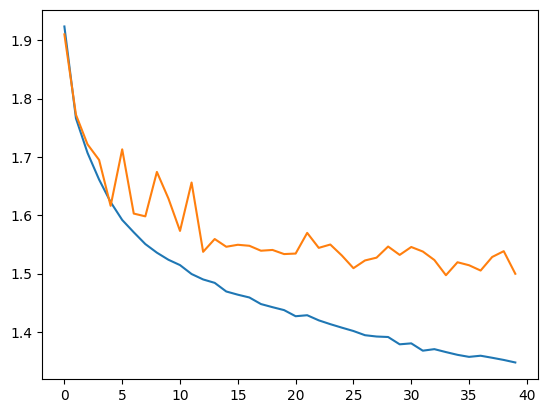

In [27]:
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])

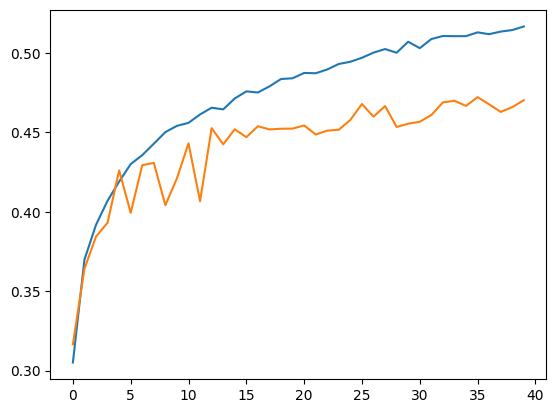

In [26]:
plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])

In [28]:
from sklearn.metrics import accuracy_score,confusion_matrix
accuracy = accuracy_score(y_pred,y_test)
cm = confusion_matrix(y_pred,y_test)

In [25]:
accuracy

0.4804

In [30]:
print(cm)

[[559  48 111  32  47  21   9  40 111  38]
 [ 27 521  19  30   9  19  15  14  48 132]
 [ 30  12 275  70 119  75  39  40   4  10]
 [ 31  32  95 325  73 230  88  89  33  33]
 [ 24  13 114  58 369  67  95  87  15  16]
 [ 17  17  74 176  52 360  44  86  16  16]
 [ 47  22 193 185 192 107 650  47  12  24]
 [ 22  18  55  32  78  45  20 488  10  39]
 [166  90  31  43  43  47  17  31 651  86]
 [ 77 227  33  49  18  29  23  78 100 606]]


Text(50.722222222222214, 0.5, 'True Label')

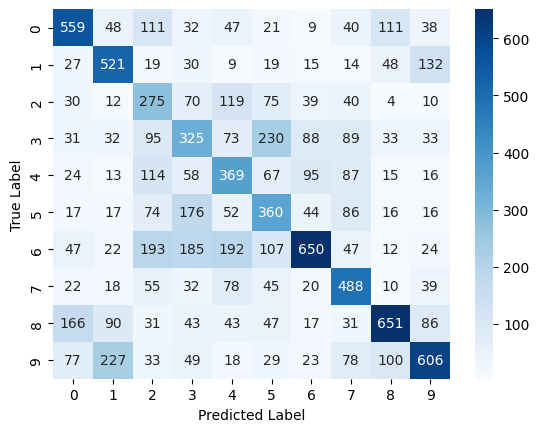

In [39]:
import seaborn as sns
sns.heatmap(cm,annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

Summary

This lab experiment demonstrates image classification using deep learning.

The CIFAR-10 dataset is used, which contains 60,000 color images of size 32×32 pixels.

The images belong to 10 different classes such as airplane, car, bird, cat, and dog.

The dataset is divided into training data and testing data.

TensorFlow and Keras libraries are used to build the model.

Image data is preprocessed by scaling pixel values to improve learning.

A Sequential neural network model is created.

A Flatten layer converts image data into one-dimensional form.

Dense layers are added to learn important features from the images.

An output layer predicts the image class.

The model is compiled using a loss function, optimizer, and accuracy metric.

The model is trained for several epochs using training data.

After training, the model is evaluated using test data.

The experiment shows how deep learning can be applied to image classification tasks.

It provides practical understanding of data loading, preprocessing, model building, training, and evaluation.